# 09 Results and Discussion

This notebook brings together the findings from the previous notebooks and discusses what they mean for the cascaded cooling system.

No new model assumptions are introduced here. The code cells are only used to load existing outputs and display the final tables and figures needed to support the discussion.

## Imports and paths

In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (
            (candidate / "outputs" / "tables" / "deterministic_baseline.csv").exists()
            and (candidate / "outputs" / "tables" / "verification_key_findings.csv").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find the project root. Please open VS Code at the repository folder.")


project_root = find_project_root()
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"
tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables output path: {tables_output_path}")
print(f"Figures output path: {figures_output_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}


Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Tables output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\tables
Figures output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\figures


## Load result outputs

In [2]:
deterministic_baseline = pd.read_csv(tables_output_path / "deterministic_baseline.csv")
monte_carlo_results = pd.read_csv(tables_output_path / "monte_carlo_results_summary.csv")
monte_carlo_most_constrained = pd.read_csv(tables_output_path / "monte_carlo_most_constrained_cases.csv")
dependency_results = pd.read_csv(tables_output_path / "dependency_results_summary.csv")
dependency_most_constrained = pd.read_csv(tables_output_path / "dependency_most_constrained_cases.csv")
sensitivity_consumer_screening = pd.read_csv(tables_output_path / "sensitivity_consumer_screening.csv")
sensitivity_doe_effects = pd.read_csv(tables_output_path / "sensitivity_fractional_factorial_effects.csv")
sensitivity_doe_interactions = pd.read_csv(tables_output_path / "sensitivity_fractional_factorial_interactions.csv")
sensitivity_key_findings = pd.read_csv(tables_output_path / "sensitivity_key_findings.csv")
verification_key_findings = pd.read_csv(tables_output_path / "verification_key_findings.csv")
verification_convergence_against_notebook06 = pd.read_csv(tables_output_path / "verification_convergence_against_notebook06.csv")
verification_convergence_stability = pd.read_csv(tables_output_path / "verification_convergence_stability.csv")

print(f"Loaded {len(deterministic_baseline):,} deterministic rows")
print(f"Loaded {len(monte_carlo_results):,} independent Monte Carlo rows")
print(f"Loaded {len(dependency_results):,} dependency Monte Carlo rows")

Loaded 6 deterministic rows
Loaded 36 independent Monte Carlo rows
Loaded 216 dependency Monte Carlo rows


## Headline findings

The main finding is that the deterministic and independent Monte Carlo assessments do not show overload, but the dependency model changes the risk position.

This is important because the cascade concentrates upstream uncertainty into the downstream systems. When loads are sampled independently, high values partly cancel out across the system. When positive dependency is introduced, high-load conditions become more likely to occur together, and the FW system becomes the limiting subsystem.

In [3]:
deterministic_fw = deterministic_baseline.loc[
    deterministic_baseline["subsystem"].eq("FW")
].sort_values("load_to_capacity_ratio", ascending=False).iloc[0]

independent_worst = monte_carlo_most_constrained.iloc[0]
dependent_worst = dependency_most_constrained.iloc[0]
convergence_comparison = verification_convergence_against_notebook06.iloc[0]

headline_results = pd.DataFrame([
    {
        "stage": "Deterministic baseline",
        "case": deterministic_fw["scenario"],
        "subsystem": deterministic_fw["subsystem"],
        "risk_metric": "Load-to-capacity ratio",
        "value": deterministic_fw["load_to_capacity_ratio"],
        "interpretation": "All deterministic loads remain below capacity; FW has the smallest margin.",
    },
    {
        "stage": "Independent Monte Carlo",
        "case": f"{independent_worst['scenario']} | {independent_worst['margin_case']} | {independent_worst['distribution_model']}",
        "subsystem": independent_worst["subsystem"],
        "risk_metric": "P99 load-to-capacity ratio",
        "value": independent_worst["p99_load_to_capacity_ratio"],
        "interpretation": "No overloads were observed; P99 remains below capacity.",
    },
    {
        "stage": "Dependency Monte Carlo",
        "case": f"{dependent_worst['scenario']} | {dependent_worst['margin_case']} | {dependent_worst['distribution_model']} | {dependent_worst['dependency_model']} | rho={dependent_worst['rho']}",
        "subsystem": dependent_worst["subsystem"],
        "risk_metric": "Overload probability (%)",
        "value": dependent_worst["overload_probability_pct"],
        "interpretation": "Positive dependency creates a material overload probability in FW.",
    },
    {
        "stage": "Extended convergence check",
        "case": "100,000 vs 1,000,000 simulations",
        "subsystem": "FW",
        "risk_metric": "Overload probability difference (percentage points)",
        "value": abs(
            convergence_comparison["notebook08_1m_overload_probability_pct"]
            - convergence_comparison["notebook08_100k_overload_probability_pct"]
        ),
        "interpretation": "The 100k result is close to the 1m long-run reference.",
    },
])

headline_results.to_csv(tables_output_path / "results_headline_summary.csv", index=False)
display(headline_results)

,stage,case,subsystem,risk_metric,value,interpretation
0,Deterministic baseline,Scenario Alpha,FW,Load-to-capacity ratio,0.952083,All deterministic loads remain below capacity;...
1,Independent Monte Carlo,Scenario Bravo | Case C - CMM + CUM + DBM + IG...,FW,P99 load-to-capacity ratio,0.978616,No overloads were observed; P99 remains below ...
2,Dependency Monte Carlo,Scenario Bravo | Case C - CMM + CUM + DBM + IG...,FW,Overload probability (%),9.225000,Positive dependency creates a material overloa...
3,Extended convergence check,"100,000 vs 1,000,000 simulations",FW,Overload probability difference (percentage po...,0.110600,The 100k result is close to the 1m long-run re...


## Deterministic baseline

The deterministic baseline shows that all subsystems pass against capacity in both scenarios. However, the FW system has the highest load-to-capacity ratio in both cases.

This means that a deterministic assessment alone would conclude that the system is acceptable, but it also identifies FW as the subsystem with the least spare margin.

In [4]:
deterministic_display = deterministic_baseline[[
    "scenario",
    "subsystem",
    "deterministic_load_kw",
    "capacity_kw",
    "spare_capacity_kw",
    "capacity_margin_pct",
    "load_to_capacity_ratio",
    "pass_fail",
]].copy()

deterministic_display = deterministic_display.sort_values(
    ["scenario", "load_to_capacity_ratio"],
    ascending=[True, False],
)

deterministic_display.to_csv(tables_output_path / "results_deterministic_summary.csv", index=False)
display(deterministic_display)

,scenario,subsystem,deterministic_load_kw,capacity_kw,spare_capacity_kw,capacity_margin_pct,load_to_capacity_ratio,pass_fail
4,Scenario Alpha,FW,11172.365578,11734.66,562.294422,4.791740,0.952083,Pass
2,Scenario Alpha,CW,3814.611478,4068.06,253.448522,6.230206,0.937698,Pass
0,Scenario Alpha,HVAC,1026.733447,1159.42,132.686553,11.444218,0.885558,Pass
5,Scenario Bravo,FW,4636.317393,4871.78,235.462607,4.833195,0.951668,Pass
3,Scenario Bravo,CW,1256.638670,1392.08,135.441330,9.729421,0.902706,Pass
1,Scenario Bravo,HVAC,307.292472,372.93,65.637528,17.600496,0.823995,Pass


## Independent Monte Carlo result

The independent Monte Carlo results do not produce overloads. The most constrained independent result is still below capacity at P99.

This does not mean there is no risk. It means that, under independent sampling, the sampled high-load events are not sufficiently aligned across the cascade to exceed capacity. Therefore the high-percentile load-to-capacity ratio is more informative than the overload probability for this stage.

In [5]:
independent_summary = monte_carlo_most_constrained.head(8)[[
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "p99_load_to_capacity_ratio",
    "p99_spare_capacity_kw",
    "overload_probability_pct",
]].copy()

independent_summary.to_csv(tables_output_path / "results_independent_monte_carlo_summary.csv", index=False)
display(independent_summary)

,scenario,margin_case,distribution_model,subsystem,p99_load_to_capacity_ratio,p99_spare_capacity_kw,overload_probability_pct
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,0.978616,104.179664,0.0
1,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,0.977572,263.181226,0.0
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,FW,0.976458,114.693661,0.0
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,FW,0.975544,286.980508,0.0
4,Scenario Bravo,Case B - CMM + CUM,Truncated normal,FW,0.956055,214.088194,0.0
5,Scenario Bravo,Case B - CMM + CUM,Triangular,FW,0.955751,215.571381,0.0
6,Scenario Alpha,Case B - CMM + CUM,Truncated normal,FW,0.954912,529.097716,0.0
7,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,0.954683,531.782573,0.0


## Dependency modelling result

The dependency model is the point at which the risk result changes. When positive dependency is introduced, the model allows high-load states to occur together across the cascade.

The worst case is Scenario Bravo, Case C, truncated normal uncertainty, global Gaussian copula, and $\rho = 0.75$. Under this assumption the FW P99 load exceeds capacity and the estimated overload probability is material.

In [6]:
dependent_summary = dependency_most_constrained.head(10)[[
    "scenario",
    "margin_case",
    "distribution_model",
    "dependency_model",
    "rho",
    "subsystem",
    "p99_load_to_capacity_ratio",
    "p99_spare_capacity_kw",
    "overload_probability_pct",
]].copy()

dependent_summary.to_csv(tables_output_path / "results_dependency_summary.csv", index=False)
display(dependent_summary)

,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,p99_load_to_capacity_ratio,p99_spare_capacity_kw,overload_probability_pct
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,1.026979,-131.437759,9.225
1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1.022912,-31.895599,4.077
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,1.021097,-102.780623,7.035
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,1.020210,-237.159811,6.942
4,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1.016671,-67.818855,4.488
5,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,1.016172,-78.785242,5.116
6,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,1.014237,-167.063648,5.077
7,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,CW,1.013280,-18.486471,2.558
8,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.50,FW,1.011560,-56.316754,3.592
9,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,1.010666,-125.165389,3.457


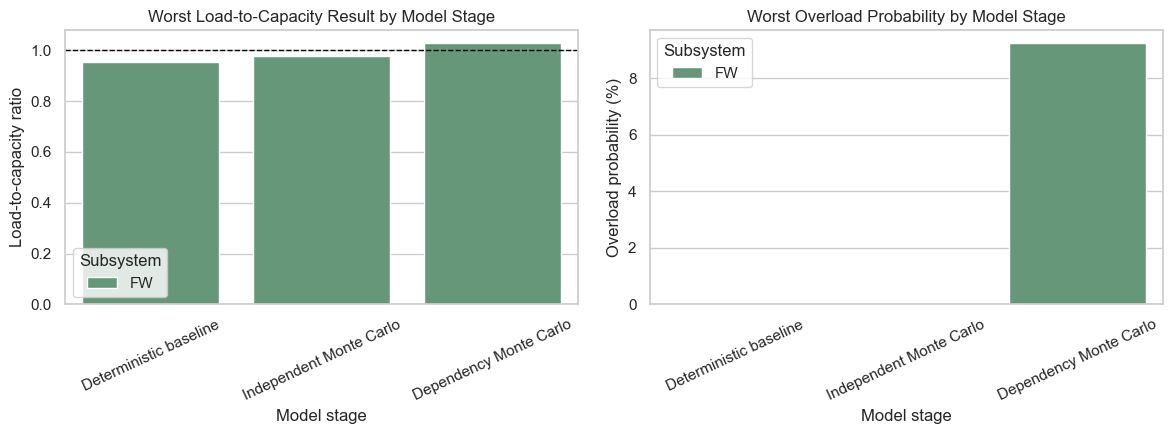

,model_stage,scenario,case,subsystem,load_to_capacity_ratio,overload_probability_pct
0,Deterministic baseline,Scenario Alpha,Baseline,FW,0.952083,0.000
1,Independent Monte Carlo,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,FW,0.978616,0.000
2,Dependency Monte Carlo,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,FW,1.026979,9.225


In [7]:
comparison_rows = []

comparison_rows.append({
    "model_stage": "Deterministic baseline",
    "scenario": deterministic_fw["scenario"],
    "case": "Baseline",
    "subsystem": deterministic_fw["subsystem"],
    "load_to_capacity_ratio": deterministic_fw["load_to_capacity_ratio"],
    "overload_probability_pct": 0.0,
})

comparison_rows.append({
    "model_stage": "Independent Monte Carlo",
    "scenario": independent_worst["scenario"],
    "case": independent_worst["margin_case"],
    "subsystem": independent_worst["subsystem"],
    "load_to_capacity_ratio": independent_worst["p99_load_to_capacity_ratio"],
    "overload_probability_pct": independent_worst["overload_probability_pct"],
})

comparison_rows.append({
    "model_stage": "Dependency Monte Carlo",
    "scenario": dependent_worst["scenario"],
    "case": dependent_worst["margin_case"],
    "subsystem": dependent_worst["subsystem"],
    "load_to_capacity_ratio": dependent_worst["p99_load_to_capacity_ratio"],
    "overload_probability_pct": dependent_worst["overload_probability_pct"],
})

stage_comparison = pd.DataFrame(comparison_rows)
stage_comparison.to_csv(tables_output_path / "results_stage_comparison.csv", index=False)

if plotting_available:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.barplot(
        data=stage_comparison,
        x="model_stage",
        y="load_to_capacity_ratio",
        hue="subsystem",
        palette=SYSTEM_PALETTE,
        dodge=False,
        ax=axes[0],
    )
    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Worst Load-to-Capacity Result by Model Stage")
    axes[0].set_xlabel("Model stage")
    axes[0].set_ylabel("Load-to-capacity ratio")
    axes[0].tick_params(axis="x", rotation=25)
    legend = axes[0].get_legend()
    if legend is not None:
        legend.set_title("Subsystem")

    sns.barplot(
        data=stage_comparison,
        x="model_stage",
        y="overload_probability_pct",
        hue="subsystem",
        palette=SYSTEM_PALETTE,
        dodge=False,
        ax=axes[1],
    )
    axes[1].set_title("Worst Overload Probability by Model Stage")
    axes[1].set_xlabel("Model stage")
    axes[1].set_ylabel("Overload probability (%)")
    axes[1].tick_params(axis="x", rotation=25)
    legend = axes[1].get_legend()
    if legend is not None:
        legend.set_title("Subsystem")

    plt.tight_layout()
    plt.savefig(figures_output_path / "results_model_stage_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

display(stage_comparison)

## Sensitivity and DoE interpretation

The sensitivity analysis links the system-level risk back to the underlying load rows and modelling assumptions.

The strongest consumer/load item is `ITEM_000076` in FW. This result is consistent across Spearman and logistic regression ranking in the focused worst case. The DoE screening shows that the largest main effect is the move from Case A to Case C, while the largest selected interaction is uncertainty case with dependency model.

This supports the interpretation that the final risk is not driven by one assumption alone. It is driven by the combination of conservative uncertainty, dependency between loads, and the downstream FW accumulation.

In [8]:
consumer_display = sensitivity_consumer_screening.head(10)[[
    "consumer_rank",
    "item_description",
    "system",
    "nominal_load_kw",
    "uncertainty_pct",
    "sample_p99_kw",
    "spearman_fw_load",
    "spearman_overload",
]].copy()

doe_display = pd.concat([
    sensitivity_doe_effects.assign(effect_group="Main effect").rename(columns={"term": "sensitivity_term", "effect": "effect_on_p99_ratio"}),
    sensitivity_doe_interactions.assign(effect_group="Interaction").rename(columns={"term": "sensitivity_term", "effect": "effect_on_p99_ratio"}),
], ignore_index=True)[[
    "effect_group",
    "sensitivity_term",
    "effect_on_p99_ratio",
    "absolute_effect",
]].sort_values("absolute_effect", ascending=False)

consumer_display.to_csv(tables_output_path / "results_top_consumer_summary.csv", index=False)
doe_display.to_csv(tables_output_path / "results_doe_summary.csv", index=False)

display(consumer_display)
display(doe_display)

,consumer_rank,item_description,system,nominal_load_kw,uncertainty_pct,sample_p99_kw,spearman_fw_load,spearman_overload
0,1,ITEM_000076,FW,886.459000,0.13,992.998259,0.922194,0.471254
1,2,ITEM_000418,FW,692.261492,0.08,743.547574,0.879246,0.454783
2,3,ITEM_000083,FW,111.398997,0.13,124.816690,0.852269,0.445864
3,4,ITEM_000788,CW,74.609229,0.18,87.042764,0.851158,0.444855
4,5,ITEM_001333,FW,100.134570,0.13,112.184123,0.849527,0.442819
5,6,ITEM_001098,CW,83.136000,0.14,93.895566,0.847944,0.441801
6,7,ITEM_000984,CW,59.805000,0.14,67.575144,0.846842,0.442395
7,8,ITEM_000983,CW,64.127000,0.14,72.467591,0.846532,0.442785
8,9,ITEM_001109,FW,76.558000,0.08,82.223582,0.846525,0.442245
9,10,ITEM_000062,CW,22.286000,0.35,29.506450,0.846473,0.441476


,effect_group,sensitivity_term,effect_on_p99_ratio,absolute_effect
0,Main effect,Uncertainty case: Case C vs Case A,0.044363,0.044363
1,Main effect,Correlation: rho 0.75 vs rho 0.25,0.009873,0.009873
2,Main effect,Dependency: global vs subsystem-block,0.008908,0.008908
5,Interaction,Uncertainty case x dependency model,0.007783,0.007783
6,Interaction,Uncertainty case x correlation,0.007698,0.007698
3,Main effect,Scenario: Bravo vs Alpha,0.002975,0.002975
7,Interaction,Dependency model x correlation,0.002574,0.002574
4,Main effect,Distribution: truncated normal vs triangular,0.002325,0.002325
8,Interaction,Scenario x uncertainty case,0.001309,0.001309
9,Interaction,Distribution x correlation,0.001046,0.001046


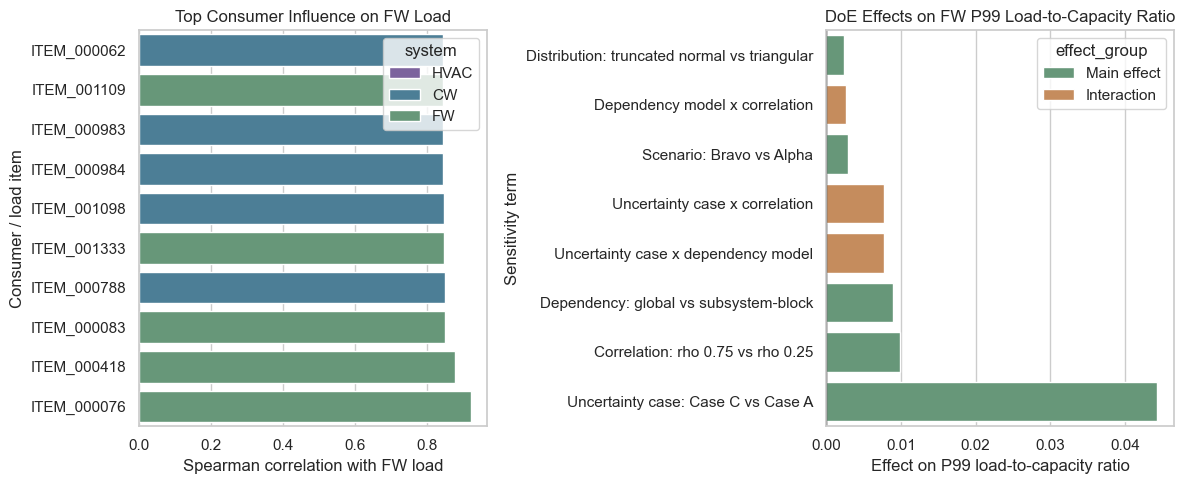

In [9]:
if plotting_available:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_consumers = consumer_display.sort_values("spearman_fw_load", ascending=True)
    sns.barplot(
        data=plot_consumers,
        x="spearman_fw_load",
        y="item_description",
        hue="system",
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        dodge=False,
        ax=axes[0],
    )
    axes[0].set_title("Top Consumer Influence on FW Load")
    axes[0].set_xlabel("Spearman correlation with FW load")
    axes[0].set_ylabel("Consumer / load item")

    plot_doe = doe_display.head(8).sort_values("effect_on_p99_ratio", ascending=True)
    sns.barplot(
        data=plot_doe,
        x="effect_on_p99_ratio",
        y="sensitivity_term",
        hue="effect_group",
        palette=[SYSTEM_PALETTE["FW"], SYSTEM_PALETTE["Ultimate Heat Sink"]],
        dodge=False,
        ax=axes[1],
    )
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title("DoE Effects on FW P99 Load-to-Capacity Ratio")
    axes[1].set_xlabel("Effect on P99 load-to-capacity ratio")
    axes[1].set_ylabel("Sensitivity term")

    plt.tight_layout()
    plt.savefig(figures_output_path / "results_sensitivity_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

## Verification and robustness

The verification notebook supports the internal robustness of the result. The model conserves cascade load propagation, sampled values remain within physical bounds, overload probabilities are consistent with increasing uncertainty, and the convergence result supports the use of 100,000 simulations in the main notebooks.

The extended convergence check is useful because it compares the 100,000-sample result against a 1,000,000-sample reference. The result changes slightly, as expected for Monte Carlo simulation, but the change is small enough that it does not alter the interpretation.

In [10]:
verification_display = verification_key_findings.copy()
verification_display.to_csv(tables_output_path / "results_verification_summary.csv", index=False)

convergence_display = verification_convergence_stability.loc[
    verification_convergence_stability["comparison"].eq("100,000 vs 1,000,000")
].copy()
convergence_display.to_csv(tables_output_path / "results_convergence_summary.csv", index=False)

display(verification_display)
display(convergence_display)

,proposal_requirement,evidence,passed
0,Conservation of load propagation through the c...,Recomputed deterministic cascade totals match ...,True
1,Enforcement of physical bounds on sampled values,Notebook 04 validation samples and the focused...,True
2,Consistency of overload probabilities with inc...,Overload probability and P99 load-to-capacity ...,True
3,Monte Carlo convergence,The worst dependent case is re-evaluated from ...,True


,comparison,metric,reference_sample_size,final_sample_size,reference_value,final_value,absolute_change,relative_change,tolerance,passed
2,"100,000 vs 1,000,000",P99 load-to-capacity ratio,100000,1000000,1.026847,1.026731,0.000116,0.000113,0.005,True
3,"100,000 vs 1,000,000",Overload probability,100000,1000000,9.178000,9.067400,0.110600,NaN,0.500,True


## Final interpretation

The results show that the cascaded system appears acceptable under deterministic and independent uncertainty assumptions. In those stages, the FW system is the most constrained subsystem, but it remains below capacity.

The conclusion changes when positive dependency is introduced. Under the most conservative dependency case, the FW P99 load exceeds capacity and the overload probability becomes material. This indicates that the main risk is not simply the size of the nominal load, but the alignment of uncertain loads across the cascade.

The result should therefore be interpreted as model-based risk evidence rather than measured plant validation. Within that modelling framework, the work shows that dependency assumptions are critical for assessing the reliability of a cascaded cooling system.

## Notebook 09 conclusion

In [11]:
results_key_findings = pd.DataFrame([
    {
        "finding": "Deterministic baseline",
        "result": "All systems pass, but FW is the most constrained subsystem.",
    },
    {
        "finding": "Independent Monte Carlo",
        "result": "No overloads are observed; the worst P99 load-to-capacity ratio remains below 1.",
    },
    {
        "finding": "Dependency Monte Carlo",
        "result": "Positive dependency creates the main risk signal; the worst FW overload probability is 9.225% in Notebook 06.",
    },
    {
        "finding": "Sensitivity",
        "result": "ITEM_000076 is the strongest consumer/load item in the focused FW sensitivity analysis.",
    },
    {
        "finding": "Verification",
        "result": "All proposal verification checks pass, and the 100k result is close to the 1m convergence reference.",
    },
])

results_key_findings.to_csv(tables_output_path / "results_key_findings.csv", index=False)
display(results_key_findings)

,finding,result
0,Deterministic baseline,"All systems pass, but FW is the most constrain..."
1,Independent Monte Carlo,No overloads are observed; the worst P99 load-...
2,Dependency Monte Carlo,Positive dependency creates the main risk sign...
3,Sensitivity,ITEM_000076 is the strongest consumer/load ite...
4,Verification,"All proposal verification checks pass, and the..."


The final conclusion is that deterministic assessment alone understates the risk in this cascaded cooling system. Independent uncertainty sampling is also not sufficient to expose the main risk. Once positive dependency is included, the downstream FW system can exceed capacity under the most conservative uncertainty case.

This supports the use of Monte Carlo simulation with dependency modelling as a more informative approach for assessing cascaded cooling reliability.